In [42]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
from torch import Tensor
from torch.nn import Linear, CrossEntropyLoss, MSELoss
from torch.optim import LBFGS
from matplotlib.colors import ListedColormap
from PIL import Image

In [43]:
# Load & process MNIST dataset:

from datasets import load_dataset
import os
import numpy as np
import json
import os
import geqie
from geqie.encodings import frqi
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit
from sklearn.model_selection import train_test_split

current_dir = os.getcwd()
# mnist_train_dataset = os.path.join("train-00000-of-00001.parquet")
# mnist_test_dataset = os.path.join("test-00000-of-00001.parquet")
mnist_train_dataset = os.path.join(".MNIST_digits", "mnist", "train-00000-of-00001.parquet")
mnist_test_dataset = os.path.join(".MNIST_digits", "mnist", "test-00000-of-00001.parquet")

path_to_train_mnist_dataset = os.path.join(current_dir, mnist_train_dataset)
path_to_test_mnist_dataset = os.path.join(current_dir, mnist_test_dataset)
def load_and_process_mnist_dataset(labels_to_include=[0, 1], 
								   n_samples_per_label=100, 
								   resize=(8, 8), 
								   path_to_mnist_dataset=None):

	mnist_dataset = load_dataset("parquet", data_files=path_to_mnist_dataset)

	selected_images = []
	images_per_label_count = {label: 0 for label in labels_to_include}
	for image_idx in range(len(mnist_dataset["train"])):
		# First, select only images with labels in labels_to_include:

		if mnist_dataset["train"][image_idx]["label"] in labels_to_include and images_per_label_count[mnist_dataset["train"][image_idx]["label"]] < n_samples_per_label:
			img_8x8 = mnist_dataset["train"][image_idx]["image"].resize(resize, resample=Image.BILINEAR)
			img = np.array(img_8x8)
			selected_images.append({"image": img, "label": mnist_dataset["train"][image_idx]["label"]})
			images_per_label_count[mnist_dataset["train"][image_idx]["label"]] += 1

	X = np.array([item["image"] for item in selected_images])
	y = np.array([item["label"] for item in selected_images])

	return X, y

def precompute_and_save_circuits(X_data, y_data, batch_size=5, save_dir="circuits"):
	if not os.path.exists(save_dir):
		os.makedirs(save_dir)
		
	num_samples = len(X_data)
	
	for i in range(0, num_samples, batch_size):
		batch_X = X_data[i : i + batch_size]
		batch_y = y_data[i : i + batch_size]
		
		batch_matrices = []
		
		for img in batch_X:
			# Encode the raw 0-255 uint8 image into a QuantumCircuit
			qc = geqie.encode(frqi.init_function, frqi.data_function, frqi.map_function, img)
			
			# Unpack the composite instructions into base gates
			flat_qc = qc.decompose()
			
			# Keep unpacking in case geqie nested them multiple layers deep
			while len(flat_qc.data) != len(flat_qc.decompose().data):
				flat_qc = flat_qc.decompose()
				
			# Filer out non-unitary gates
			pure_qc = QuantumCircuit(flat_qc.num_qubits)
			for instruction in flat_qc.data:
				# Handle different Qiskit version data structures safely
				op_name = instruction.operation.name if hasattr(instruction, 'operation') else instruction[0].name
				
				# Now that the 'reset' is exposed, this will catch and delete it!
				if op_name not in ['reset', 'measure', 'barrier']:
					pure_qc.append(instruction)
			
			# Extract the exact unitary matrix using Qiskit Operator
			unitary_matrix = Operator(pure_qc).data
			
			# Cast as complex128 to preserve strict unitarity
			unitary_matrix = np.array(unitary_matrix, dtype=np.complex128)
			batch_matrices.append(unitary_matrix)
			
		# Save to .npz file
		batch_filename = os.path.join(save_dir, f"batch_{i//batch_size}.npz")
		np.savez(batch_filename, matrices=batch_matrices, labels=batch_y)
		
		print(f"Saved {batch_filename} with dtype {batch_matrices[0].dtype}")

def precompute_and_save_split(
	X_data,
	y_data,
	batch_size=5,
	save_dir="circuits",
	split_name="train"
):
	split_dir = os.path.join(save_dir, split_name)
	os.makedirs(split_dir, exist_ok=True)

	num_samples = len(X_data)
	batch_files = []

	for i in range(0, num_samples, batch_size):
		batch_X = X_data[i:i + batch_size]
		batch_y = y_data[i:i + batch_size]

		batch_matrices = []

		for img in batch_X:
			qc = geqie.encode(
				frqi.init_function,
				frqi.data_function,
				frqi.map_function,
				img
			)

			flat_qc = qc.decompose()
			while len(flat_qc.data) != len(flat_qc.decompose().data):
				flat_qc = flat_qc.decompose()

			pure_qc = QuantumCircuit(flat_qc.num_qubits)
			for instruction in flat_qc.data:
				op_name = (
					instruction.operation.name
					if hasattr(instruction, "operation")
					else instruction[0].name
				)

				if op_name not in ["reset", "measure", "barrier"]:
					pure_qc.append(instruction)

			unitary_matrix = np.array(Operator(pure_qc).data, dtype=np.complex128)
			batch_matrices.append(unitary_matrix)

		batch_filename = os.path.join(split_dir, f"batch_{i // batch_size:04d}.npz")
		np.savez_compressed(
			batch_filename,
			matrices=np.array(batch_matrices, dtype=np.complex128),
			labels=np.array(batch_y)
		)
		batch_files.append(batch_filename)

		print(f"[{split_name}] saved: {batch_filename}")

	metadata = {
		"split_name": split_name,
		"num_samples": int(num_samples),
		"batch_size": int(batch_size),
		"num_batches": int(len(batch_files)),
		"files": [os.path.basename(f) for f in batch_files],
	}

	with open(os.path.join(split_dir, "metadata.json"), "w", encoding="utf-8") as f:
		json.dump(metadata, f, indent=2)

	return split_dir

def prepare_train_val_precomputed(
	X,
	y,
	val_size=0.2,
	batch_size=5,
	save_dir="circuits",
	random_state=42,
	stratify=True
):
	stratify_labels = y if stratify else None

	X_train, X_val, y_train, y_val = train_test_split(
		X,
		y,
		test_size=val_size,
		random_state=random_state,
		shuffle=True,
		stratify=stratify_labels
	)

	train_dir = precompute_and_save_split(
		X_train,
		y_train,
		batch_size=batch_size,
		save_dir=save_dir,
		split_name="train"
	)

	val_dir = precompute_and_save_split(
		X_val,
		y_val,
		batch_size=batch_size,
		save_dir=save_dir,
		split_name="val"
	)

	return {
		"X_train": X_train,
		"y_train": y_train,
		"X_val": X_val,
		"y_val": y_val,
		"train_dir": train_dir,
		"val_dir": val_dir,
	}

def prepare_test_precomputed(
	X,
	y,
	batch_size=5,
	save_dir="circuits",
	random_state=42,
	stratify=True
):
	stratify_labels = y if stratify else None

	test_dir = precompute_and_save_split(
		X,
		y,
		batch_size=batch_size,
		save_dir=save_dir,
		split_name="test"
	)

	return {
		"X_test": X,
		"y_test": y,
		"test_dir": test_dir,
	}





In [90]:
from sklearn.preprocessing import LabelEncoder
LABELS_TO_INCLUDE=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
N_SAMPLES_PER_CLASS_TRAIN=25

label_encoder = LabelEncoder()
label_encoder.fit(LABELS_TO_INCLUDE)


X_train_val, y_train_val = load_and_process_mnist_dataset(
    labels_to_include=LABELS_TO_INCLUDE,
	n_samples_per_label=N_SAMPLES_PER_CLASS_TRAIN, 
	resize=(8, 8), 
	path_to_mnist_dataset=path_to_train_mnist_dataset)

y_train_val = label_encoder.transform(y_train_val)

NUM_CLASSES = np.unique(y_train_val).shape[0]

prepared_train_val = prepare_train_val_precomputed(
	X_train_val,
	y_train_val,
	val_size=0.2,
	batch_size=5,
	save_dir="circuits",
	random_state=42,
	stratify=True
)
train_dir = prepared_train_val["train_dir"]
val_dir = prepared_train_val["val_dir"]

X_test, y_test = load_and_process_mnist_dataset(
    labels_to_include=LABELS_TO_INCLUDE, 
    n_samples_per_label=int(N_SAMPLES_PER_CLASS_TRAIN*0.2), 
    resize=(8, 8), 
    path_to_mnist_dataset=path_to_test_mnist_dataset)
y_test = label_encoder.transform(y_test)

prepared_test  = prepare_test_precomputed(
	X_test,
	y_test,
	batch_size=5,
	save_dir="circuits",
	random_state=42,
	stratify=True
)
test_dir = prepared_test["test_dir"]

[train] saved: circuits\train\batch_0000.npz
[train] saved: circuits\train\batch_0001.npz
[train] saved: circuits\train\batch_0002.npz
[train] saved: circuits\train\batch_0003.npz
[train] saved: circuits\train\batch_0004.npz
[train] saved: circuits\train\batch_0005.npz
[train] saved: circuits\train\batch_0006.npz
[train] saved: circuits\train\batch_0007.npz
[train] saved: circuits\train\batch_0008.npz
[train] saved: circuits\train\batch_0009.npz
[train] saved: circuits\train\batch_0010.npz
[train] saved: circuits\train\batch_0011.npz
[train] saved: circuits\train\batch_0012.npz
[train] saved: circuits\train\batch_0013.npz
[train] saved: circuits\train\batch_0014.npz
[train] saved: circuits\train\batch_0015.npz
[train] saved: circuits\train\batch_0016.npz
[train] saved: circuits\train\batch_0017.npz
[train] saved: circuits\train\batch_0018.npz
[train] saved: circuits\train\batch_0019.npz
[train] saved: circuits\train\batch_0020.npz
[train] saved: circuits\train\batch_0021.npz
[train] sa

In [91]:
import time

import glob
import torch
import numpy as np
import torch.nn as nn
from torch.nn import Linear, CrossEntropyLoss, MSELoss, NLLLoss
from torch.optim import LBFGS, Adam
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import UnitaryGate
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient
from qiskit_machine_learning.connectors.torch_connector import _TorchNNFunction
from tqdm import tqdm

import geqie
from geqie.encodings import frqi

class QNN_Pythorch_Module(nn.Module):
	def __init__(self, num_classes, num_qubits=7, num_layers=3):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_classes = num_classes
		
		# 1. Create the parameterized VQC circuit ONCE
		self.vqc_circuit = QuantumCircuit(num_qubits)
		self.thetas = ParameterVector("theta", length=3 * num_qubits * num_layers)
		
		# Apply the brickwork architecture to the VQC circuit
		for layer in range(num_layers):
			offset = layer * 3 * num_qubits
			for i in range(num_qubits):
				self.vqc_circuit.rx(self.thetas[offset + i], i)
			for i in range(num_qubits):
				self.vqc_circuit.ry(self.thetas[offset + num_qubits + i], i)
			for i in range(num_qubits):
				self.vqc_circuit.rz(self.thetas[offset + 2*num_qubits + i], i)
			
			# Alternating brickwork entanglement
			if layer % 2 == 0:
				for i in range(0, num_qubits - 1, 2):
					self.vqc_circuit.cx(i, i + 1)
			else:
				for i in range(1, num_qubits - 1, 2):
					self.vqc_circuit.cx(i, i + 1)
				self.vqc_circuit.cx(num_qubits - 1, 0)
		
		# 2. Register the quantum weights directly as a native PyTorch Parameter.
		# Initialized from -pi to pi so the gates are fully active!
		self.quantum_weight = nn.Parameter(
			torch.empty(len(self.thetas)).uniform_(-np.pi, np.pi)
		)
		
		# 3. Classical head
		self.classical_head = nn.Linear(2**num_qubits, num_classes)

	def forward(self, matrix, default_shots=8192):
		# Build a clean, fresh circuit for this specific image safely
		qc = QuantumCircuit(self.num_qubits)
		qc.append(UnitaryGate(matrix), range(self.num_qubits))
		qc.compose(self.vqc_circuit, inplace=True)
		
		# Build the SamplerQNN using the active parameters
		fresh_sampler = Sampler(default_shots=default_shots)
		fresh_qnn = SamplerQNN(
			circuit=qc,
			input_params=None,
			weight_params=list(qc.parameters),
			sampler=fresh_sampler,
			gradient=ParamShiftSamplerGradient(sampler=fresh_sampler)
		)
		
		# Use raw PyTorch Autograd to bind our master weight to the QNN.
		# This completely bypasses TorchConnector's restrictive initialization.
		probs = _TorchNNFunction.apply(
			torch.empty(0),                 # input_data
			self.quantum_weight,  # weights (Our registered nn.Parameter!)
			fresh_qnn,            # neural_network
			False                 # sparse
		)
		# Feature scaling, drastically improves training time
		# Feels illegal, but it works, just don't let the gradient police know
		scaled_probs = probs * (2 ** self.num_qubits)
		
		# Classical classification
		logits = self.classical_head(scaled_probs)
		return torch.log_softmax(logits, dim=-1)
	
def load_precomputed_batches(split_dir):
    batch_files = sorted(glob.glob(os.path.join(split_dir, "batch_*.npz")))

    for batch_file in batch_files:
        data = np.load(batch_file, allow_pickle=True)
        matrices = data["matrices"]
        labels = data["labels"]
        yield matrices, labels

def train_QNN(epochs=20, num_classes=len(LABELS_TO_INCLUDE), train_dir=None, val_dir=None) -> dict:
	f_loss = NLLLoss()
	qnn_model = QNN_Pythorch_Module(num_classes=num_classes, num_qubits=7, num_layers=1)
	
	optimizer = Adam([
		{'params': qnn_model.quantum_weight, 'lr': 0.05},
		{'params': qnn_model.classical_head.parameters(), 'lr': 0.001}
	])
	
	qnn_model.train()
	# loss_list = []
	progress_bar_training = tqdm(range(epochs), desc="Training")
	quantum_layer_weights_history = []
	classical_head_weights_history = []
	train_losses = []
	val_losses = []	
	
	for epoch in range(epochs):
		qnn_model.train()		

		for (i, (matrices, labels)) in enumerate(load_precomputed_batches(train_dir)):			
			for matrix, label in zip(matrices, labels):
				matrix_tensor = matrix
				label_tensor = torch.tensor([label], dtype=torch.long)

				output = qnn_model(matrix_tensor)
				if output.dim() == 1:			# To ensure the output matches
					output = output.unsqueeze(0)

				loss = f_loss(output, label_tensor)

				optimizer.zero_grad()
				loss.backward()
				optimizer.step()

		quantum_layer_weights_history.append(qnn_model.quantum_weight.detach().cpu().numpy().copy().flatten())
		classical_head_weights_history.append(qnn_model.classical_head.weight.detach().cpu().numpy().copy().flatten())	

		train_losses.append(loss.item())
		postfix = {"loss": f"{loss.item():.2f}"}			

		qnn_model.eval()
		correct = 0
		total = 0

		with torch.no_grad():
			for matrices, labels in load_precomputed_batches(val_dir):
				for matrix, label in zip(matrices, labels):
					label_tensor = torch.tensor([label], dtype=torch.long)

					output = qnn_model(matrix)
					if output.dim() == 1: 		# To ensure the output matches
						output = output.unsqueeze(0)

					loss = f_loss(output, label_tensor)						

					pred = output.argmax(dim=1).item()
					correct += int(pred == label)
					total += 1

		val_losses.append(loss.item())
		postfix["val_loss"] = f"{loss.item():.2f}"

		val_acc = correct / total if total > 0 else 0.0
		# print(
		# 	f"Epoch {epoch+1}: "
		# 	f"train_loss={np.mean(train_losses):.4f}, "
		# 	f"val_loss={np.mean(val_losses):.4f}, "
		# 	f"val_acc={val_acc:.4f}"
		# )

		progress_bar_training.update(1)
		progress_bar_training.set_postfix(postfix)			

	return {'train_losses': train_losses, 
		 'val_losses': val_losses, 
		 'qnn_model': qnn_model, 
		 'quantum_layer_weights_history': quantum_layer_weights_history, 
		 'classical_head_weights_history': classical_head_weights_history}

In [92]:
results_dict = train_QNN(
    epochs=15,
    num_classes=np.unique(y_train_val).shape[0],
    train_dir=train_dir,
    val_dir=val_dir
)

Training: 100%|██████████| 15/15 [1:24:49<00:00, 339.29s/it, loss=0.36, val_loss=0.22]


### Test

In [93]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def test_QNN(qnn_model=None, test_dir=test_dir):
	''' 
	This function takes trained QNN model and evaluates it based on the test set.
	Returns classification statistics together with confusion matrix.
	Supports multiclass classification.
	'''

	if qnn_model is None:
		raise ValueError("Parameter 'qnn_model' cannot be None.")

	qnn_model.eval()

	y_true = []
	y_pred = []
	test_losses = []

	f_loss = NLLLoss()

	with torch.no_grad():
		for matrices, labels in load_precomputed_batches(test_dir):
			for matrix, label in zip(matrices, labels):
				label_tensor = torch.tensor([int(label)], dtype=torch.long)

				output = qnn_model(matrix)
				if output.dim() == 1: 		# To ensure the output matches
					output = output.unsqueeze(0)
				loss = f_loss(output, label_tensor)
				test_losses.append(loss.item())

				pred = output.argmax(dim=1).item()

				y_true.append(int(label))
				y_pred.append(int(pred))

	if len(y_true) == 0:
		raise ValueError(f"No samples found in test_dir='{test_dir}'.")

	# Determine labels present in y_true and y_pred
	labels = list(range(NUM_CLASSES))

	cm = confusion_matrix(y_true, y_pred, labels=labels)
	acc = accuracy_score(y_true, y_pred)

	# For multiclass case, weighted average is usually the safest default
	precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
	recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
	f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

	cls_report = classification_report(
		y_true,
		y_pred,
		labels=labels,
		zero_division=0
	)

	results = {
		"test_loss": float(np.mean(test_losses)),
		"accuracy": float(acc),
		"precision_weighted": float(precision),
		"recall_weighted": float(recall),
		"f1_weighted": float(f1),
		"confusion_matrix": cm,
		"labels": labels,
		"classification_report": cls_report,
		"y_true": y_true,
		"y_pred": y_pred
	}

	print(f"Test loss:  {results['test_loss']:.4f}")
	print(f"Accuracy:   {results['accuracy']:.4f}")
	print(f"Precision:  {results['precision_weighted']:.4f}")
	print(f"Recall:     {results['recall_weighted']:.4f}")
	print(f"F1-score:   {results['f1_weighted']:.4f}")
	print("\nConfusion matrix:")
	print(results["confusion_matrix"])
	print("\nClassification report:")
	print(results["classification_report"])

	return results


In [94]:
test_results = test_QNN(qnn_model=results_dict['qnn_model'], test_dir=test_dir)

Test loss:  1.4011
Accuracy:   0.6200
Precision:  0.7422
Recall:     0.6200
F1-score:   0.6025

Confusion matrix:
[[5 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [2 0 3 0 0 0 0 0 0 0]
 [1 0 2 1 0 1 0 0 0 0]
 [0 0 0 0 4 0 0 0 1 0]
 [0 0 1 0 0 3 0 0 1 0]
 [0 0 3 0 0 0 2 0 0 0]
 [1 0 0 0 0 0 0 4 0 0]
 [0 0 1 0 0 1 0 0 3 0]
 [0 0 0 0 2 1 0 1 0 1]]

Classification report:
              precision    recall  f1-score   support

           0       0.56      1.00      0.71         5
           1       1.00      1.00      1.00         5
           2       0.30      0.60      0.40         5
           3       1.00      0.20      0.33         5
           4       0.67      0.80      0.73         5
           5       0.50      0.60      0.55         5
           6       1.00      0.40      0.57         5
           7       0.80      0.80      0.80         5
           8       0.60      0.60      0.60         5
           9       1.00      0.20      0.33         5

    accuracy                       

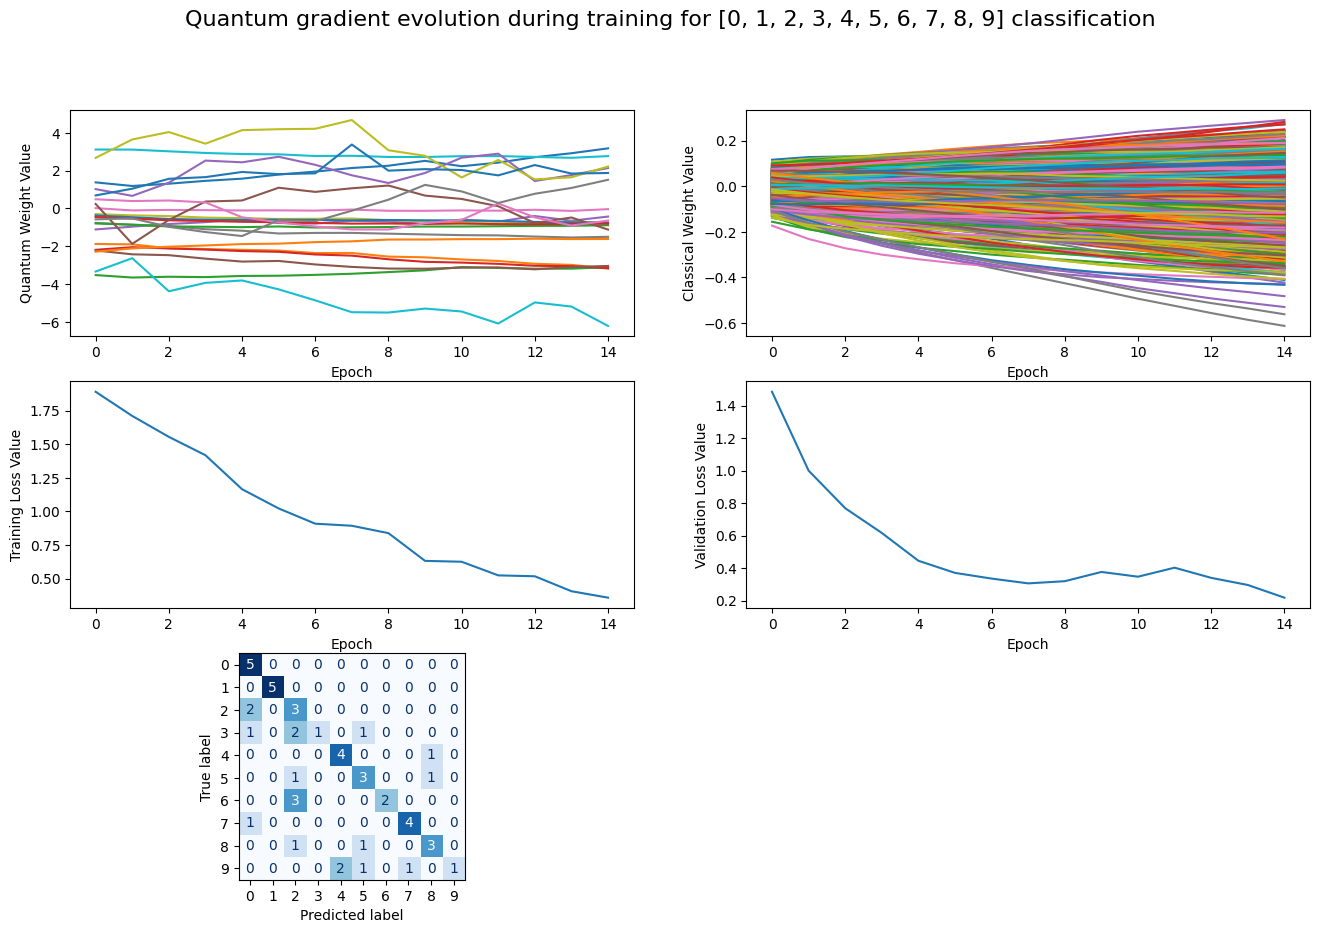

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(f"Quantum gradient evolution during training for {LABELS_TO_INCLUDE} classification", fontsize=16)
quantum_weights_history = np.array(results_dict['quantum_layer_weights_history'])
for i in range(quantum_weights_history.shape[1]):
	ax[0, 0].plot(quantum_weights_history[:, i], label=f"Theta {i}")
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Quantum Weight Value")

classical_weights_history = np.array(results_dict['classical_head_weights_history'])
for i in range(classical_weights_history.shape[1]):
	ax[0, 1].plot(classical_weights_history[:, i], label=f"Weight {i}")
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Classical Weight Value")


ax[1, 0].plot(results_dict['train_losses'], label="Train Loss")
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Training Loss Value")


ax[1, 1].plot(results_dict['val_losses'], label="Validation Loss")
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Validation Loss Value")

cm = test_results["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS_TO_INCLUDE)
disp.plot(ax=ax[2, 0], cmap=plt.cm.Blues, colorbar=False)

ax[2, 1].axis("off")  # Hide the empty subplot

plt.show()